Libraries


In [5]:
# Import core data science and utility libraries
import pandas as pd
import numpy as np
from google.colab import files
import os

# Install specialized Hijri calendar library
!pip install ummalqura
from ummalqura.hijri_date import HijriDate



Data Ingestion (Direct Path)

In [7]:
# Define the file path (Ensure the file is uploaded to the Colab files section)
file_path = 'SuperMarket Analysis.csv'

# Check if file exists before reading
if os.path.exists(file_path):
    # Load the dataset directly
    df = pd.read_csv(file_path)

    # Convert 'Date' column to standard datetime format
    df['Date'] = pd.to_datetime(df['Date'])

    print(f"Success: '{file_path}' loaded directly.")
else:
    print(f"Error: '{file_path}' not found. Please upload it to the Colab file sidebar.")

# Preview the data
df.head()

Success: 'SuperMarket Analysis.csv' loaded directly.


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


Localization & Feature Engineering





In [9]:

# 1. Dictionary for English Hijri month names
hijri_months_en = {
    1: 'Muharram', 2: 'Safar', 3: 'Rabi Al-Awwal', 4: 'Rabi Al-Thani',
    5: 'Jumada Al-Ula', 6: 'Jumada Al-Akhira', 7: 'Rajab', 8: 'Shaaban',
    9: 'Ramadan', 10: 'Shawwal', 11: 'Dhu Al-Qidah', 12: 'Dhu Al-Hijjah'
}

def get_localized_data(date):
    # Convert to Hijri object
    hj = HijriDate(date.year, date.month, date.day, gr=True)

    # Get the English name from our dictionary
    month_en = hijri_months_en.get(hj.month)

    return hj.day, hj.month, month_en, hj.year

# 2. Extract and Map Hijri features
df['Hijri_Day'], df['Hijri_Month_Num'], df['Hijri_Month_Name'], df['Hijri_Year'] = zip(*df['Date'].map(get_localized_data))

# 3. Define Logic for Saudi Seasonal events
def assign_saudi_season(row):
    if row['Hijri_Month_Num'] == 9:
        return 'Ramadan'
    elif row['Hijri_Month_Num'] == 10 and row['Hijri_Day'] <= 3:
        return 'Eid Al-Fitr'
    elif row['Hijri_Month_Num'] == 12 and row['Hijri_Day'] >= 1 and row['Hijri_Day'] <= 13:
        return 'Hajj Season'
    elif row['Date'].month in [12, 1, 2]:
        return 'Winter'
    else:
        return 'Regular'

# 4. Apply labels and add cities
df['Season'] = df.apply(assign_saudi_season, axis=1)
df['City'] = np.random.choice(['Makkah', 'Riyadh', 'Jeddah', 'Dammam', 'Madinah'], size=len(df))

# 5. Preview results
df[['Date', 'Hijri_Month_Name', 'Season', 'City']].head(10)

,Date,Hijri_Month_Name,Season,City
0,2019-01-05,Rabi Al-Thani,Winter,Madinah
1,2019-03-08,Rajab,Regular,Makkah
2,2019-03-03,Jumada Al-Akhira,Regular,Riyadh
3,2019-01-27,Jumada Al-Ula,Winter,Makkah
4,2019-02-08,Jumada Al-Akhira,Winter,Dammam
5,2019-03-25,Rajab,Regular,Madinah
6,2019-02-25,Jumada Al-Akhira,Winter,Makkah
7,2019-02-24,Jumada Al-Akhira,Winter,Jeddah
8,2019-01-10,Jumada Al-Ula,Winter,Jeddah
9,2019-02-20,Jumada Al-Akhira,Winter,Jeddah




Visualizing the localized data (Preview)



In [11]:

# Select specific columns to see the transformation clearly
preview_columns = ['Date', 'City', 'Hijri_Month_Name', 'Season', 'Product line', 'Sales']

# Display the first 15 rows of the modified data
df[preview_columns].head(15)

,Date,City,Hijri_Month_Name,Season,Product line,Sales
0,2019-01-05,Madinah,Rabi Al-Thani,Winter,Health and beauty,548.9715
1,2019-03-08,Makkah,Rajab,Regular,Electronic accessories,80.2200
2,2019-03-03,Riyadh,Jumada Al-Akhira,Regular,Home and lifestyle,340.5255
3,2019-01-27,Makkah,Jumada Al-Ula,Winter,Health and beauty,489.0480
4,2019-02-08,Dammam,Jumada Al-Akhira,Winter,Sports and travel,634.3785
5,2019-03-25,Madinah,Rajab,Regular,Electronic accessories,627.6165
6,2019-02-25,Makkah,Jumada Al-Akhira,Winter,Electronic accessories,433.6920
7,2019-02-24,Jeddah,Jumada Al-Akhira,Winter,Home and lifestyle,772.3800
8,2019-01-10,Jeddah,Jumada Al-Ula,Winter,Health and beauty,76.1460
9,2019-02-20,Jeddah,Jumada Al-Akhira,Winter,Food and beverages,172.7460


Data Aggregation for Time-Series Modeling

In [12]:


# 1. Group data by Date to get total daily sales
# We sum the 'Sales' and take the first 'Season' and 'City' found for that day
daily_sales = df.groupby('Date').agg({
    'Sales': 'sum',
    'Season': 'first',
    'City': 'first',
    'Hijri_Month_Num': 'first'
}).reset_index()

# 2. Sort by date to ensure chronological order
daily_sales = daily_sales.sort_values('Date')

# 3. Set Date as index (Required for S-ARIMAX)
daily_sales.set_index('Date', inplace=True)

# 4. Handle any missing dates by resampling to 'D' (Daily) and filling with 0
daily_sales = daily_sales.resample('D').asfreq()
daily_sales['Sales'] = daily_sales['Sales'].fillna(0)
# Fill categorical gaps with 'Regular' season and a default city
daily_sales['Season'] = daily_sales['Season'].fillna('Regular')
daily_sales['City'] = daily_sales['City'].fillna('Makkah')

# Preview the prepared time-series data
print("Daily Sales Preview (Ready for AI):")
daily_sales.head(10)

Daily Sales Preview (Ready for AI):


,Sales,Season,City,Hijri_Month_Num
Date,,,,
2019-01-01,4745.1810,Winter,Jeddah,4
2019-01-02,1945.5030,Winter,Jeddah,4
2019-01-03,2078.1285,Winter,Jeddah,4
2019-01-04,1623.6885,Winter,Riyadh,4
2019-01-05,3536.6835,Winter,Madinah,4
2019-01-06,3614.2050,Winter,Riyadh,4
2019-01-07,2834.2440,Winter,Makkah,5
2019-01-08,5293.7325,Winter,Makkah,5
2019-01-09,3021.3435,Winter,Jeddah,5


Training the S-ARIMAX Model

In [13]:
import statsmodels.api as sm

# 1. Prepare Exogenous variables (The 'X' in ARIMAX)
# Convert 'Season' text into numbers (Categorical encoding)
daily_sales['Season_Code'] = daily_sales['Season'].astype('category').cat.codes
exog = daily_sales[['Season_Code']]

# 2. Define the Model (Seasonal ARIMA + Exogenous)
# Order (p,d,q) and Seasonal Order (P,D,Q,s)
# Note: 's=7' means weekly seasonality
model = sm.tsa.statespace.SARIMAX(
    daily_sales['Sales'],
    exog=exog,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
)

# 3. Fit the model (The 'Learning' process)
results = model.fit(disp=False)

# 4. Predict the next 30 days
# We create future dates and assume they are 'Regular' season for now
forecast_steps = 30
forecast_exog = pd.DataFrame({'Season_Code': [0] * forecast_steps}) # Assume normal days
forecast = results.get_forecast(steps=forecast_steps, exog=forecast_exog)

print("AI Training Complete. Future predictions generated!")

AI Training Complete. Future predictions generated!


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Visualizing Actual vs Forecasted Sales


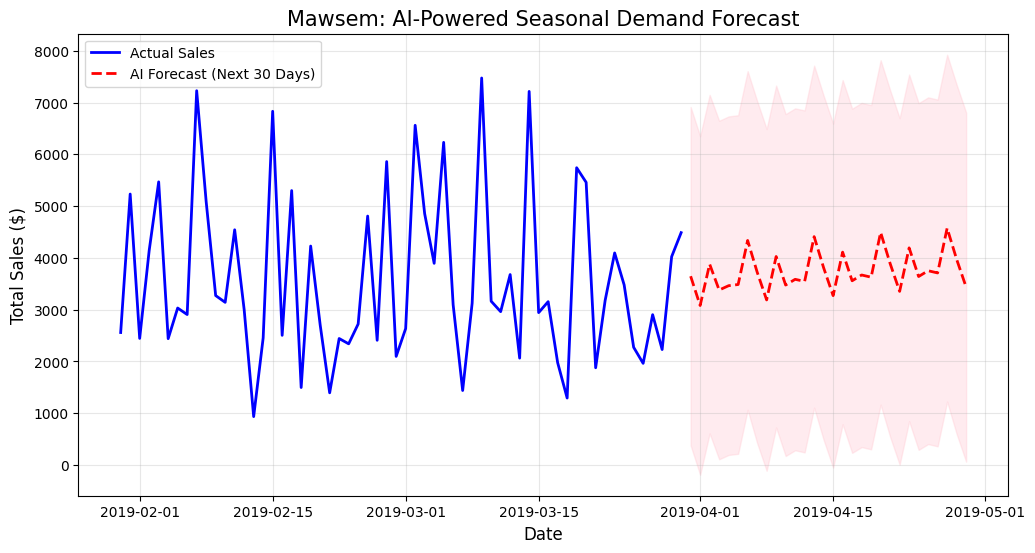

In [14]:
import matplotlib.pyplot as plt

# 1. Get the forecast values and confidence intervals
forecast_series = forecast.predicted_mean
conf_int = forecast.conf_int()

# 2. Create the plot
plt.figure(figsize=(12, 6))

# Plot historical data (Last 60 days for clarity)
plt.plot(daily_sales['Sales'].tail(60), label='Actual Sales', color='blue', linewidth=2)

# Plot the AI forecast
plt.plot(forecast_series, label='AI Forecast (Next 30 Days)', color='red', linestyle='--', linewidth=2)

# Fill the confidence interval area
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)

# 3. Formatting the chart for the presentation
plt.title('Mawsem: AI-Powered Seasonal Demand Forecast', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Show the final result
plt.show()